In [2]:
%pip install matplotlib
!mkdir -p fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf \
-O fonts/NanumGothic.ttf
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont('fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 음수 부호 깨짐 방지


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 45.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 42.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 46.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
rng = np.random.default_rng(13) # 숙제 번호 13을 시드로 (재현 가능성)
N = 150
genre = rng.choice(['뉴스', '소설', '대화', '학술'], size=N, p=[0.3, 0.3, 0.2, 0.2])
base = {'뉴스': 22, '소설': 18, '대화': 9, '학술': 28} # 장르별 평균 어절 수
words = (np.array([base[g] for g in genre]) + rng.normal(0, 5, N)).clip(3, 60)
words = words.round().astype(int)
syllables = (words * 2.5 + rng.normal(0, 4, N)).clip(5, None).round().astype(int)
read_time = (syllables * 0.35 + rng.normal(0, 1.5, N)).clip(1, None).round(1)
difficulty = (words * 0.15 + rng.normal(0, 1.2, N)).clip(1, 10).round(1)
texts = pd.DataFrame({'장르': genre,
'어절수': words,
'음절수': syllables,
'읽기시간': read_time,
'난이도': difficulty,
})
# 연도별 신문/소설의 외래어 비율(%) (가상 데이터)
trends = pd.DataFrame({
'연도': [1990, 1995, 2000, 2005, 2010, 2015, 2020],
'뉴스': [5.1, 6.3, 8.0, 9.4, 11.2, 13.5, 15.1],
'소설': [3.2, 3.5, 4.0, 4.6, 5.1, 5.8, 6.4],
})

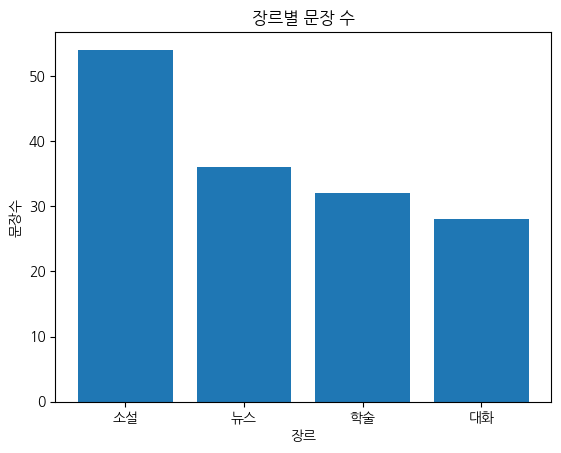

In [ ]:
#Q1-a
genre_counts = texts['장르'].value_counts()
fig, ax = plt.subplots()
ax.bar(genre_counts.index, genre_counts.values)
ax.set_title("장르별 문장 수")
ax.set_xlabel('장르')
ax.set_ylabel('문장수')
ax.set_ylim(0,)
plt.show()
#value_counts를 통해 장르별 문장수를 가져오고 그것을 각각 x,y 값으로 한다. 막대 그래프이므로 bar 그래프를 그리고 set_x,ylabel을 통해 x축과 y축을 정해준다. 그리고 set_ylim을 통해 y가 0에서 시작할 수 있게 만들어줄 수 있다 

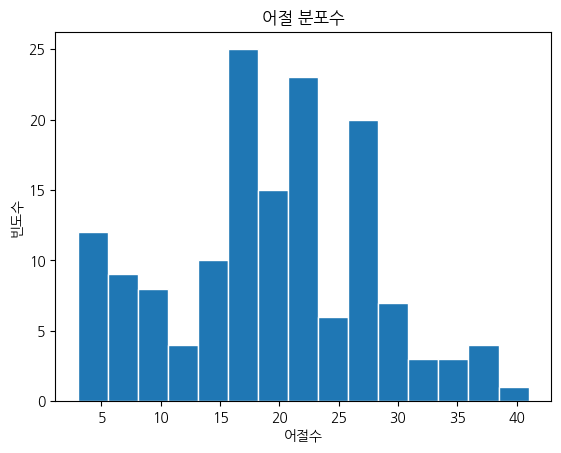

In [ ]:
#Q1-b
fig, ax=plt.subplots()
ax.hist(texts['어절수'],bins=15,edgecolor='white')
ax.set_title('어절 분포수')
ax.set_xlabel('어절수')
ax.set_ylabel('빈도수')
plt.show()
#관찰:어절 수는 대체로 15~30어절 구간에 많이 몰려 있다.
#설명: texts에서 어절수만 가져와서 히스토그램을 그린다. 어떤 어절수가 가장 많이 등장하는지 보여주는 것이기 때문에 y축의 이름이 '빈도수'이고 set_ylabel로 설정한다

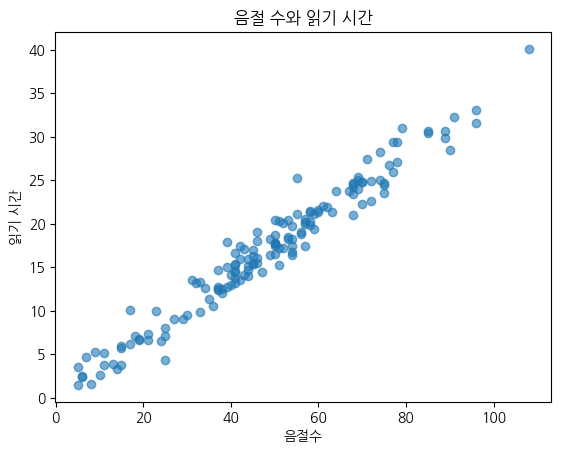

In [ ]:
#Q1-c
fig, ax=plt.subplots()
ax.scatter(texts['음절수'],texts['읽기시간'],alpha=0.6)
ax.set_title('음절 수와 읽기 시간')
ax.set_xlabel('음절수')
ax.set_ylabel('읽기 시간')
plt.show()
#관찰: 두 변수는 우상향 관계를 보인다
#산점도를 그리고 싶기 때문에 scatter를 쓴다. 그리고 음절수와 읽기시간을 각각 x,y로 만들고 싶기 때문에 texts에서 가져온다

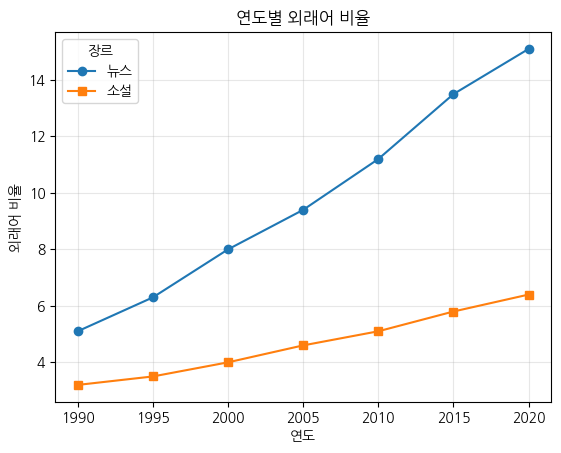

In [ ]:
#2-a
fig, ax=plt.subplots()
ax.plot(trends["연도"],trends['뉴스'],marker="o",label='뉴스')
ax.plot(trends['연도'],trends['소설'],marker='s',label='소설')
ax.set_title('연도별 외래어 비율')
ax.set_xlabel('연도')
ax.set_ylabel('외래어 비율')
ax.legend(title='장르')
ax.grid(True, alpha=0.3)
plt.show()
#관찰:뉴스와 소설 모두 시간이 지날수록 외래어 비율이 증가하지만, 뉴스의 외래어 비율이 소설보다 더 높고 증가 폭도 더 크다.
#설명:trends 데이터에서 연도를 x축으로 두고, 뉴스와 소설의 외래어 비율을 각각 하나의 선으로 그렸다. 각 선에는 marker와 label을 지정했으며, legend(title='장르')로 범례를 표시하고 grid(True, alpha=0.3)으로 옅은 격자를 추가했다.

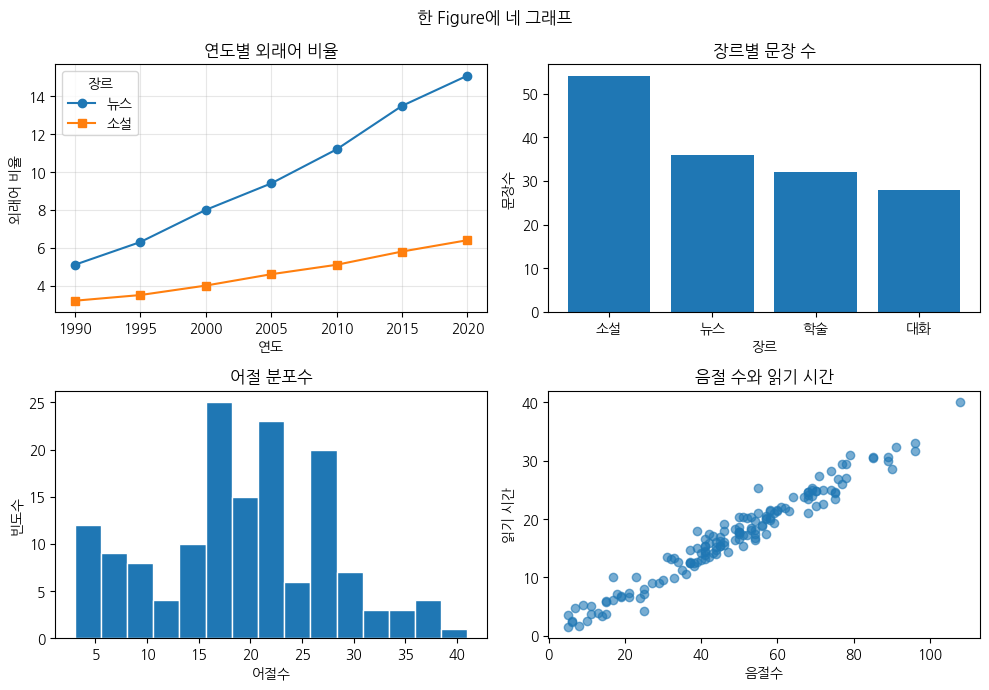

In [ ]:
#2-b
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0,0].plot(trends["연도"],trends['뉴스'],marker="o",label='뉴스')
axes[0,0].plot(trends['연도'],trends['소설'],marker='s',label='소설')
axes[0,0].set_title('연도별 외래어 비율')
axes[0,0].set_xlabel('연도')
axes[0,0].set_ylabel('외래어 비율')
axes[0,0].legend(title='장르')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].bar(genre_counts.index, genre_counts.values)
axes[0,1].set_title("장르별 문장 수")
axes[0,1].set_xlabel('장르')
axes[0,1].set_ylabel('문장수')
axes[0,1].set_ylim(0,)

axes[1,0].hist(texts['어절수'],bins=15,edgecolor='white')
axes[1,0].set_title('어절 분포수')
axes[1,0].set_xlabel('어절수')
axes[1,0].set_ylabel('빈도수')

axes[1,1].scatter(texts['음절수'],texts['읽기시간'],alpha=0.6)
axes[1,1].set_title('음절 수와 읽기 시간')
axes[1,1].set_xlabel('음절수')
axes[1,1].set_ylabel('읽기 시간')
fig.suptitle('한 Figure에 네 그래프')
fig.tight_layout()
fig.savefig('hw13_subplots.png', dpi=150, bbox_inches='tight')
plt.show()
#이 코드는 앞에서 만든 네 가지 그래프를 `plt.subplots(2, 2)`를 이용해 하나의 Figure 안에 2행 2열로 배치한 것이다.각 위치의 `axes`에 선 그래프, 막대 그래프, 히스토그램, 산점도를 각각 그린 뒤, 전체 제목을 붙이고 이미지 파일로 저장한다.



In [14]:
%pip install seaborn
import seaborn as sns


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Text(0.5, 1.0, '장르별 색칠')

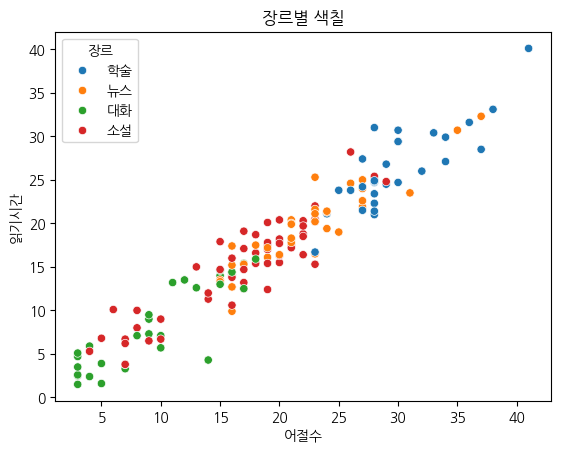

In [ ]:
#Q3-a
fig, ax = plt.subplots()
sns.scatterplot(data=texts,x='어절수',y='읽기시간',hue='장르',ax=ax)
ax.set_title('장르별 색칠')
#texts 데이터에서 어절수와 읽기시간의 관계를 산점도로 나타내고, hue='장르'를 사용해 장르별로 점의 색을 다르게 표시한 것이다.ax=ax를 지정해서 seaborn 그래프가 미리 만든 matplotlib 축 위에 그려지도록 하고, 마지막에 그래프 제목을 붙였다.

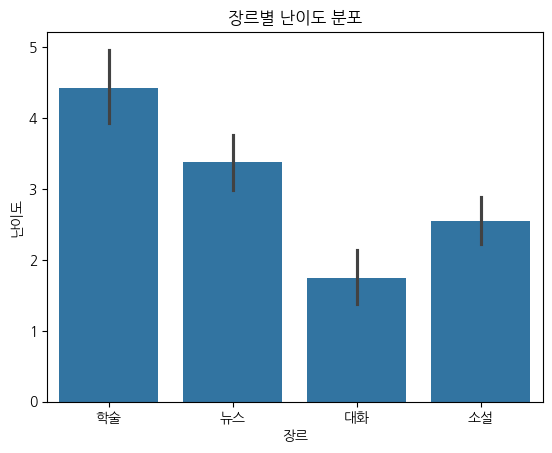

In [ ]:
#Q3-b
fig,ax=plt.subplots()
sns.barplot(data=texts,x='장르',y='난이도',ax=ax)
ax.set_title('장르별 난이도 분포')
plt.show()
#관찰: 평균 난이도는 학술이 가장 높고, 난이도의 퍼짐도 학술이 가장 크다.
#설명: texts 데이터에서 장르별 평균 난이도를 막대그래프로 나타낸 것이다.sns.barplot()은 각 장르의 난이도 평균을 계산해 보여주며, ax=ax로 미리 만든 그래프 영역에 그리도록 지정했다.

Text(0.5, 1.0, '변수간 상관계수')

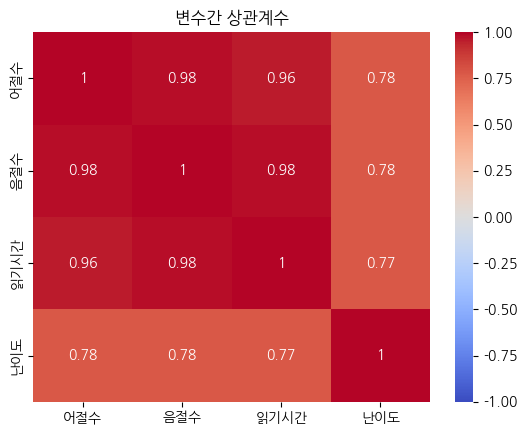

In [ ]:
#Q3-c
corr= texts[['어절수', '음절수', '읽기시간', '난이도']].corr()
fig,ax=plt.subplots()
sns.heatmap(corr, annot=True,cmap='coolwarm',vmin=-1,vmax=1,ax=ax)
ax.set_title('변수간 상관계수')
#관찰: 가장 강한 상관관계를 가진 것은 음절수와 어절수, 그리고 음절수와 읽기 시간이다. 각각의 수가 0.98로 가장 크기 때문이다
#설명: 어절수, 음절수, 읽기시간, 난이도 네 변수 사이의 상관계수를 corr()로 계산한 뒤, 이를 heatmap으로 시각화한 것이다. annot=True로 각 칸에 상관계수 값을 표시하고, vmin=-1, vmax=1을 지정해 상관계수 범위를 -1부터 1까지로 고정했다.


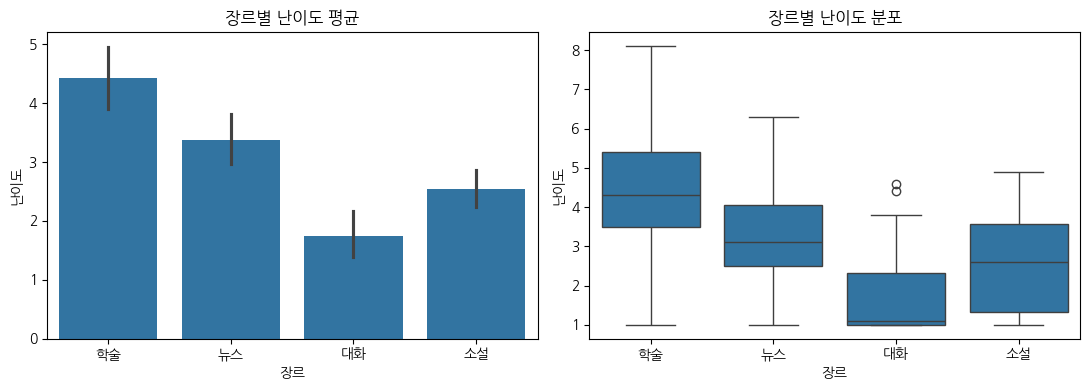

In [ ]:
#Q4-a
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(data=texts, x='장르', y='난이도', ax=axes[0])
axes[0].set_title('장르별 난이도 평균')
axes[0].set_xlabel('장르')
axes[0].set_ylabel('난이도')

sns.boxplot(data=texts, x='장르', y='난이도', ax=axes[1])
axes[1].set_title('장르별 난이도 분포')
axes[1].set_xlabel('장르')
axes[1].set_ylabel('난이도')

plt.tight_layout()
plt.show()
#서술: 왼쪽 막대 그래프는 장르별 평균 난이도만 보여주기 때문에, 각 장르 안에서 난이도가 얼마나 넓게 퍼져 있는지나 이상값이 있는지는 알기 어렵다. 반면 오른쪽 상자그림은 중앙값, 분포의 범위, 퍼짐 정도를 함께 보여준다. 예를 들어 두 장르의 평균 난이도가 비슷하더라도, 한 장르는 난이도가 평균 근처에 몰려 있고 다른 장르는 낮은 값과 높은 값이 넓게 퍼져 있을 수 있다.
#설명: 이 코드는 plt.subplots(1, 2)를 사용해 두 개의 그래프를 가로로 배치한 것이다. 왼쪽에는 sns.barplot()으로 장르별 난이도의 평균을, 오른쪽에는 sns.boxplot()으로 장르별 난이도의 분포와 퍼짐 정도를 나타냈다.

In [ ]:
mean_words = texts.groupby('장르')['어절수'].mean()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# 왼쪽: y축을 잘라서 그림
ax[0].bar(mean_words.index, mean_words.values)
ax[0].set_title('장르별 평균 어절 수')
ax[0].set_xlabel('장르')
ax[0].set_ylabel('평균 어절 수')
ax[0].set_ylim(15, 30)

# 오른쪽: y축을 0부터 그림
ax[1].bar(mean_words.index, mean_words.values)
ax[1].set_title('장르별 평균 어절 수')
ax[1].set_xlabel('장르')
ax[1].set_ylabel('평균 어절 수')
ax[1].set_ylim(0, 30)

plt.tight_layout()
plt.show()
#설명:이 코드는 groupby('장르')['어절수'].mean()으로 장르별 평균 어절 수를 구한 뒤, 같은 데이터를 두 개의 막대그래프로 나란히 그린 것이다. 왼쪽 그래프는 y축을 15부터 시작하게 잘라서 그리고, 오른쪽 그래프는 y축을 0부터 시작하게 설정했다.
#서술:두 그래프는 같은 평균 어절 수를 보여주지만, 왼쪽 그래프는 y축이 15부터 시작하기 때문에 장르 간 차이가 실제보다 훨씬 크게 보인다. 반면 오른쪽 그래프처럼 y축을 0부터 시작하면 막대의 전체 높이를 비교할 수 있어 차이를 더 정직하게 보여준다. 막대그래프는 막대의 길이 자체로 크기를 비교하게 하므로, y축을 0부터 그리지 않으면 시각적으로 과장된 인상을 줄 수 있다.

In [ ]:
#https://chatgpt.com/share/6a202436-3708-83a7-aa65-722e365efe73